# <center>**Enhancing LEM-X Imaging with the IROS Reconstruction Pipeline**<center>

## <center>**Sky Reconstruction Efficiency**<center>

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from regions import Regions, PixCoord, TextPixelRegion, RegionVisual

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask, count
from bloodmoon.io import simulation_files
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

plt.rcdefaults()

In [2]:
# MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
MASK_FITS: str = "mask_NTHT_20250725.fits"

# SKYFIELD: str = "IROSDummy"
SKYFIELD: str = "GalacticCentre"
# DATA_FITS: str = "baseline_2-50keV_1ks"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks_mask25"

RUN_ID: str = 'GC_smoothed_rec_1ks_2-50keV_mask25'

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

E_min: float = 2.0  # [keV]
E_max: float = 50.0  # [keV]
coords2exclude: list[CoordEquatorial] | None = None

UPS_X, UPS_Y = 2, 1
hide_bulk_els_y: float = 1.5   # [mm]

In [3]:
MASK_PATH, SIMUL_DATA_PATH, SAVE_PATH = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    runID=RUN_ID,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y, hide_bulk_els_y=hide_bulk_els_y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_min, E_max=E_max, coords=coords2exclude)
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET], E_min=E_min, E_max=E_max, coords=coords2exclude)
catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

logA, logB = ds.load_database(f"{SAVE_PATH}/IROS_sources_db.fits")
cu_map = mgm.get_srcmap_for_unit(logA.log['ID'], logB.log['ID'])

# Loading data...
# Loading completed!


In [4]:
def show_detector(
    camera: CodedMaskCamera,
    detector: NDArray,
    save_to: str | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Shows input 2D detector array.
    """
    def _center_lbls(bins: NDArray) -> tuple[NDArray, NDArray]:
        """Centers ticks and respective labels values."""
        # - extend the detector's size to a square [-80, 80] mm
        # - divide in 9 equispaced values and drop edges
        step = int(1 / abs(bins[0] - bins[1]))
        offset = int(abs(bins[-1] - 80.0))
        new_len = len(bins) + 2 * offset * step
        els = np.linspace(0, new_len - 1, 9, dtype=int)[1 : -1] - offset * step
        return els, bins[els].astype(int)

    xbins, ybins = camera.bins_detector
    img_layout = {
        'cmap': 'viridis', 'origin': 'lower', 'interpolation': 'none',
        'aspect': detector.shape[1] / detector.shape[0],
    }

    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    img = ax.imshow(detector, vmin=np.unique(detector)[1], **img_layout)
    cbar = fig.colorbar(img, ax=ax, location='bottom', shrink=0.4, pad=0.03)
    cbar.set_label('counts [ph]')
    
    ax.xaxis.set_label_position('top'); ax.yaxis.set_label_position('right')
    ax.set_xlabel(xlabel='Fine Axis [mm]', labelpad=7)
    ax.set_ylabel(ylabel='Coarse Axis [mm]', rotation=270, labelpad=17)
    ax.xaxis.tick_top(); ax.yaxis.tick_right()
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
    ax.set_xticks(*_center_lbls(xbins))
    ax.set_yticks(*_center_lbls(ybins))

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return

def show_composed_skymap(
    image: NDArray,
    wcs: WCS,
    reg: Regions | None = None,
    save_to: str | None = None,
    ticks_spacing: int | float = 20,
    txt_visual: dict[str, Any] | None = None,
    txt_offset: tuple[int, int] = (5, 20),
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """
    Plots the LEM-X Unit composed skymap with reconstructed sources from IROS.\n
    CFR w: [composed GalCentre](https://github.com/yuri-evangelista/CodedMasks/blob/main/mask_050_1040x17/Plot_IROS_Composed_Image.ipynb).
    """
    img_layout = {
        'cmap': 'viridis', 'origin': 'lower', 'interpolation': 'none', 'norm': 'log',
    }

    fig = plt.figure(tight_layout=True, **fig_kws)
    wcsax = WCSAxes(fig, 111, wcs=wcs)
    fig.add_axes(wcsax)

    # config ticks
    for crd in wcsax.coords:
        crd.set_ticklabel_visible(False)
        crd.set_ticks_visible(False)

    # confing `galactic` overlay
    overlay = wcsax.get_coords_overlay('galactic')
    overlay.grid(visible=True, linewidth=0.15, alpha=0.2)
    axs_lbl = ('Galactic Longitude [deg]', 'Galactic Latitude [deg]')
    for lbl, ovl in zip(axs_lbl, overlay):
        ovl.set_axislabel(lbl)
        ovl.set_major_formatter('d')
        ovl.set_ticks(spacing=ticks_spacing * u.degree)
        ovl.tick_params(which='both', direction='in', width=1.5, length=3 if 'major' else 2)
        # ovl.set_ticklabel(fontsize=PLOTPARAMS['ticklabel_fs'], fontweight=PLOTPARAMS['label_fw'])
    
    img = wcsax.imshow(image, **img_layout)
    cbar = fig.colorbar(
        img, ax=wcsax, location='bottom', shrink=0.4, pad=0.03,
    )
    # cbar.ax.tick_params(labelsize=PLOTPARAMS['ticklabel_fs'])
    cbar.set_label('SNR')

    # insert region info
    if reg is not None:
        txt_visual_ = txt_visual or {}
        visual = RegionVisual(txt_visual_)
        delta = PixCoord(*txt_offset)
        for src in reg:
            text = src.meta['text']
            pixel_region = src.to_pixel(wcs)
            pixel_region.plot(ax=wcsax)
            txt = TextPixelRegion(center=pixel_region.center + delta, text=text, visual=visual)
            txt.plot(ax=wcsax)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()

    return


In [5]:
detector = count(wfm, sdlA.DLdata)[0]

compIROS_true_path = f"{SAVE_PATH}/COMPOSED_sky_SIMUL_CAM1A_CAM1B.fits"
compIROS_out_path = f"{SAVE_PATH}/COMPOSED_OUTsky_IROS_CAM1A_CAM1B.fits"
reg_file_path = f"{SAVE_PATH}/OUTregionfile_IROS_CAM1B.reg"

true_comp, wcs = mgm.open_ImageHDU(compIROS_true_path, ext=2)
out_comp, _ = mgm.open_ImageHDU(compIROS_out_path, ext=2)
# reg = np.array(Regions.read(reg_file_path, format='ds9'))[cu_map.idx_b]
reg = Regions.read(reg_file_path, format='ds9')

# transf: Callable = lambda x: np.pow(np.clip(x, a_min=0.5, a_max=20), 0.75)
transf: Callable = lambda x: np.clip(x, a_min=1, a_max=None)

UserInfo: using bulk mask of [0.0 x 1.5] mm.


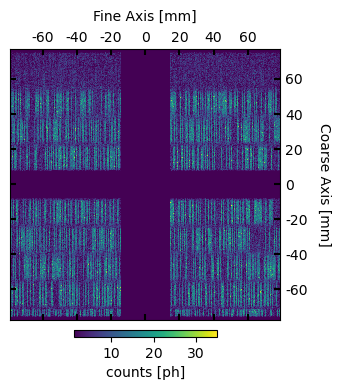

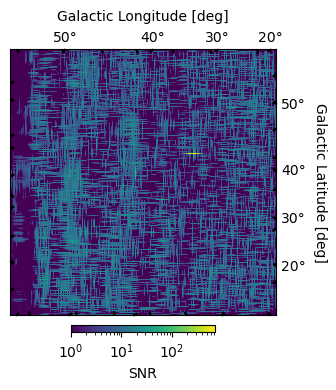

In [6]:
FIGSIZE = (4, 4)

show_detector(wfm, detector, save_to=f'{OUT_RESULTS_PATH}/detector_CAM1A.pdf', figsize=FIGSIZE)

KWS_comp = {
    'ticks_spacing': 10,
    'figsize': FIGSIZE,
}
show_composed_skymap(
    image=transf(true_comp),
    wcs=wcs,
    save_to=f'{OUT_RESULTS_PATH}/composed_TRUESKY.pdf',
    **KWS_comp,
)

/home/starfloyd/PhD_Coding/LearningCodedMasks/newSG/LearningCodedMasks/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/home/starfloyd/PhD_Coding/LearningCodedMasks/newSG/LearningCodedMasks/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/home/starfloyd/PhD_Coding/LearningCodedMasks/newSG/LearningCodedMasks/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/home/starfloyd/PhD_Coding/LearningCodedMasks/newSG/LearningCodedMasks/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/home/starfloyd/PhD_Coding/LearningCoded

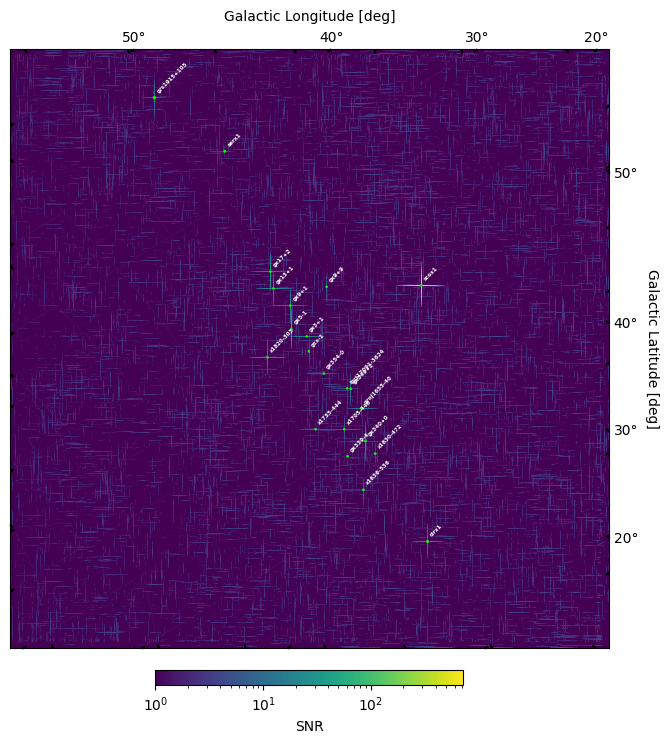

In [ ]:
KWS_comp = {
    'ticks_spacing': 10,
    'txt_offset': (10, 30),
    'txt_visual': {'textangle': 45, 'color': 'white', 'fontsize': 4, 'fontweight': 'bold'},
    'figsize': (8.0, 8.0),
}
show_composed_skymap(
    image=transf(out_comp),
    wcs=wcs,
    reg=reg,
    # save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY.pdf',
    # save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY.svg',
    save_options=dict(bbox_inches='tight'),
    **KWS_comp,
)

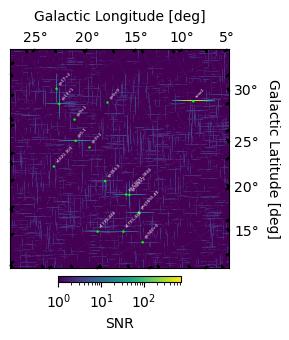

In [8]:
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord

from bloodmoon.coords import angle2shift, shift2equatorial

def angle2equatorial(camera, sdl, theta_x, theta_y) -> tuple[float, float]:
    sx, sy = map(lambda theta: angle2shift(camera, theta), (theta_x, theta_y))
    return shift2equatorial(sdl, camera, sx, sy)

tx, ty = 0.0, 6.0

POS: tuple[float, float] = angle2equatorial(wfm, sdlA, tx, ty)
SIZE: tuple[int, int] = (1350, 1350)
cutout = Cutout2D(transf(out_comp), SkyCoord(ra=POS[0], dec=POS[1], frame='fk5', unit='deg'), SIZE, wcs=wcs)


KWS_comp = {
    'ticks_spacing': 5,
    'txt_offset': (10, 30),
    'txt_visual': {'textangle': 45, 'color': 'white', 'fontsize': 3},
    'figsize': (3.5, 3.5),
}
show_composed_skymap(
    image=transf(cutout.data),
    wcs=cutout.wcs,
    reg=reg,
    save_to=f'{OUT_RESULTS_PATH}/composed_OUTSKY_cutout.pdf',
    **KWS_comp,
)

### <center>**Sources Localisation Efficiency**<center>

In [5]:
def compose(a: NDArray, b: NDArray) -> NDArray:
    return np.sqrt(a ** 2 + b ** 2)

def get_symlimits(arr: NDArray, offset: float | None = None) -> tuple[float, float]:
    """Returns symmetric `arr` boundary centered around abs max value."""
    m = np.abs(arr).max()
    if offset: m += offset
    return -m, m

def show_coordsRes_vs_snr(
    crdres_fine_A: NDArray,
    crdres_fine_B: NDArray,
    snrvals: NDArray,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
    ) -> None:
    """Plots the coordinates residues along fine directions."""
    lims_offset = 0.1

    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    pts_fine = ax.scatter(crdres_fine_A, crdres_fine_B, c=snrvals, cmap='viridis', norm='log')
    cbar = fig.colorbar(
        pts_fine, ax=ax, location='right', shrink=0.75, pad=0.03,
    )
    cbar.set_label('SNR')
    ax.set_xlim(*get_symlimits(crdres_fine_A, offset=lims_offset))
    ax.set_ylim(*get_symlimits(crdres_fine_B, offset=lims_offset))
    
    ax.set_xlabel(xlabel='$\\Delta\\theta_{\\text{fine}}^{\\text{A}}$ [arcmin]')
    ax.set_ylabel(ylabel='$\\Delta\\theta_{\\text{fine}}^{\\text{B}}$ [arcmin]')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)

    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return

Analysing LEMX-CAM1BS1: 100%|██████████| 20/20 [00:00<00:00, 165.45it/s]


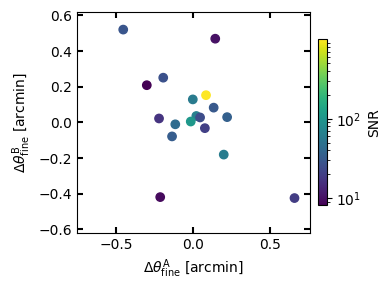

In [9]:
crdres_fine_A, _ = mgm.get_angularcoords_residues(logA, catA, sdlA, wfm)
crdres_fine_B, _ = mgm.get_angularcoords_residues(logB, catB, sdlB, wfm)

snr = compose(np.array(logA.log['snr'])[cu_map.idx_a], np.array(logB.log['snr'])[cu_map.idx_b])

show_coordsRes_vs_snr(
    crdres_fine_A[cu_map.idx_a], crdres_fine_B[cu_map.idx_b], snr,
    save_to=f'{OUT_RESULTS_PATH}/camUnit_src_coords_res.pdf',
    figsize=(4, 3),
)

### <center>**Sources Statistics**<center>

In [7]:
def show_snrDistr_evol(
    hist_true: NDArray,
    hist_res: NDArray,
    bins: NDArray,
    save_to: str | Path | None = None,
    save_options: dict[str, Any] | None = None,
    **fig_kws,
) -> None:
    """Plots the SNR distr. evolution at 1st and last IROS iters."""
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.stairs(hist_true, edges=bins, edgecolor='OrangeRed', label='1st iter.')
    ax.stairs(hist_res, edges=bins, edgecolor='DodgerBlue', label='last iter.')
    ax.set_xlabel(xlabel='SNR')
    ax.set_ylabel(ylabel='density')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
    ax.legend(loc='best')
    if save_to is not None:
        save_options_ = save_options or {}
        fig.savefig(save_to, **save_options_)
    plt.show()
    return

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


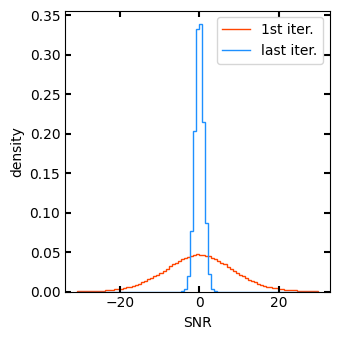

In [10]:
# SNR distr. vs coding noise reduction (true sky --> last IROS iteration)
ycut, xcut = UPS_Y * 30, UPS_X * 20
num_bins = 1000
density = True
distr_lims = (-30, 30)

# - CAMERA A
_, true_skysnr = ds.load_sky(f'{SAVE_PATH}/sky_SIMUL_CAM1A.fits')
_, res_skysnr = ds.load_sky(f'{SAVE_PATH}/skyRES_IROS_CAM1A.fits')

true_skysnr = ds.unframe(true_skysnr, ycut, xcut)
res_skysnr = ds.unframe(res_skysnr, ycut, xcut)

hist_true_skysnr, bins = np.histogram(true_skysnr, bins=num_bins, density=density)
hist_res_skysnr, _ = np.histogram(res_skysnr, bins=bins, density=density)
bins_slice, hist_slice = ds.config_distr_limits(bins, *distr_lims)

show_snrDistr_evol(
    hist_true_skysnr[hist_slice], hist_res_skysnr[hist_slice], bins[bins_slice],
    save_to=f'{OUT_RESULTS_PATH}/snr_distr_vs_codnoise.pdf',
    figsize=(3.5, 3.5),
)

### <center>**Estimate Weaker Source**<center>

In [ ]:
from numpy.typing import NDArray

from bloodmoon.coords import equatorial2shift
from darksun.benchmarking import source_catalogue_data
from darksun.data import Log, DataLoader, CatalogueLoader
from darksun.analyze import get_effective_area

def find_weaker_src(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    idx_map: NDArray | None = None,
) -> tuple[str, int]:
    """Finds the weaker detected source during the IROS sky reconstruction."""
    true_cts = mgm.extract_catalogue_fluences(log, catalogue, sdl, camera)
    ids, cts = map(lambda x: x[idx_map], (np.array(logA.log['ID']), true_cts))
    src = str(ids[int(np.argmin(cts))])
    return src, int(cts.min())

def compute_src_flx(
    sourceID: str,
    cts: int,
    camera: CodedMaskCamera,
    sdl: DataLoader,
    catalogue: CatalogueLoader
) -> float:
    """Computes the instrumental flux of given source."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    sx, sy = equatorial2shift(sdl, camera, data['RA'], data['DEC'])
    eff_area = get_effective_area(camera, sx, sy)
    exposure = sdl.header['EXPOSURE']
    return float(cts / eff_area / exposure)


src, cts = find_weaker_src(logA, catA, sdlA, wfm, cu_map.idx_a)
flx = compute_src_flx(src, cts, wfm, sdlA, catA)

Analysing GX349+2:  10%|▉         | 2/21 [00:00<00:07,  2.51it/s]

## USING BULK MASK with 1.5 mm cover ##


Analysing LEMX-CAM1AS3: 100%|██████████| 21/21 [00:02<00:00,  7.98it/s]  


In [8]:
src, cts, flx / 10

('serx1', 6974, 0.23580977516892393)

In [14]:
flx = compute_src_flx('serx1', 7842, wfm, sdlB, catB)

'serx1', 7842, flx / 10

('serx1', 7842, 0.23801930039061941)

In [ ]:
def comp_combflx() -> float:
    ctsA, ctsB = 6974, 7842
    data = source_catalogue_data('serx1', catA.DLdata)
    sx, sy = equatorial2shift(sdlA, wfm, data['RA'], data['DEC'])
    eff_area = get_effective_area(wfm, sx, sy) + get_effective_area(wfm, sy, -sx)
    return (ctsA + ctsB) / eff_area / 1e3

comp_combflx() / 2.7 * (5 / 9.1) * np.sqrt(1e3)

np.float64(1.524985719150381)